<style>
.jp-Notebook, .jp-Cell, body.jp-Notebook, .cell, div#notebook, .notebook {
  background-color: #0f1115 !important;
}
.jp-RenderedMarkdown, .rendered_html, .jp-RenderedHTMLCommon {
  color: #e6e6e6 !important; font-size: 16px; line-height: 1.6;
}
.jp-RenderedMarkdown h1, .jp-RenderedMarkdown h2, .jp-RenderedMarkdown h3,
.rendered_html h1, .rendered_html h2, .rendered_html h3 { color: #8ec7ff !important; }
.jp-RenderedMarkdown h1, .rendered_html h1 {
  border-bottom: 2px solid #2b4a6f; padding-bottom: .2em;
}
.jp-RenderedMarkdown a, .rendered_html a { color: #7fd1c1 !important; }
.jp-RenderedMarkdown code, .rendered_html code {
  background: #1b2430 !important; color: #ffd479 !important;
  padding: 1px 5px; border-radius: 4px;
}
.jp-RenderedMarkdown pre, .rendered_html pre {
  background: #1b2430 !important; color: #e6e6e6 !important;
  border-left: 3px solid #2b4a6f; padding: .6em .9em; border-radius: 6px;
}
.jp-RenderedMarkdown blockquote, .rendered_html blockquote {
  border-left: 4px solid #7fd1c1; color: #bcd; background: #141a22;
  padding: .3em 1em; border-radius: 0 6px 6px 0;
}
.jp-RenderedMarkdown table, .rendered_html table { color: #e6e6e6; }
.jp-RenderedMarkdown th, .rendered_html th { background: #1b2430 !important; }
</style>


# NB39 · Equilibrio en movimiento: el punto de captura y el ZMP

**Parte 5 · La física del cuerpo — Lección 4**

> En el **NB38** descubriste la regla del equilibrio **quieto**: no te caes mientras la vertical de tu centro de masas esté dentro de tu base de apoyo. Y al final, una pregunta incómoda: cuando andas, tu centro de masas **se sale** de la base constantemente. ¿Por qué no te caes?

La respuesta es que **sí te caes**... pero pones el pie a tiempo, en el sitio justo. Hoy vamos a convertir esa frase en matemáticas, y vamos a calcular **dónde** es "el sitio justo".

Para ello usaremos el modelo más famoso de la locomoción con patas: el **péndulo invertido lineal**. Con él descubriremos el **punto de captura** (el lugar exacto donde tienes que pisar para frenarte) y el **ZMP**, el concepto con el que andaba **ASIMO**, el famoso robot humanoide de Honda. Y al final, con unas pocas líneas de código, haremos **andar** a un robot de juguete encadenando caídas.

Es el notebook con más física de la parte, pero vamos a ir despacio, y casi todo saldrá de dos cosas que ya sabes: la **segunda ley de Newton** (NB37) y la **cadena de oro** de los pasitos (NB07).


## 1 · Antes de nada: ¿qué es un modelo?

Un robot humanoide de verdad tiene docenas de piezas, cada una con su masa, su forma y su inercia, unidas por articulaciones con motores, rozamientos y holguras. Calcular **exactamente** lo que le pasa es lo que hace MuJoCo, con miles de cuentas por paso. Una persona no puede **pensar** así.

Por eso los ingenieros usan **modelos**: versiones **simplificadas** a propósito, que se quedan solo con lo esencial y tiran todo lo demás. Un modelo es como un **mapa de metro**: no dibuja las calles, ni los edificios, ni las curvas reales de los túneles. Es "mentira" en casi todo... y aun así es **perfecto** para saber en qué estación cambiar de línea. Los científicos lo resumen en una frase: **"el mapa no es el territorio"**. Y otra, del estadístico George Box: **"todos los modelos están mal, pero algunos son útiles"**.

Ya usaste un modelo: la física del palo de escoba del NB11 era la de verdad, **linealizada** (NB37). Hoy usaremos uno parecido para un robot que anda.


## 2 · El robot como un péndulo invertido

Primera simplificación, muy atrevida: imagina que **toda la masa** del robot está concentrada en **un solo punto**, su **centro de masas** (NB38). Y que la pierna de apoyo es un **palo sin masa** que va del pie a ese punto.

```
              ●  ← toda la masa del robot, en su centro de masas
             ╱
            ╱   pierna de apoyo (sin masa)
           ╱
   ═══════▲═══════════  suelo
          pie (el punto de apoyo)
```

¡Es el palo de escoba del NB11 y del NB37! Un **péndulo invertido**: un peso encima de un palo apoyado en el suelo. Si el centro de masas está justo encima del pie, en equilibrio (inestable). Si está un poco adelantado, se cae hacia delante, cada vez más deprisa.

Parece una simplificación absurda (¡un robot no es un palo!), pero captura lo esencial: la mayor parte de la masa de un humano o de un humanoide está en el **tronco**, a una cierta altura, y apoyada sobre **una pierna** durante gran parte de cada paso.


## 3 · El péndulo invertido **lineal**

Segunda simplificación, y esta es la buena. Cuando un péndulo invertido normal se cae, su centro de masas **baja** (recorre un arco, como en el NB37). Pero un robot con **rodillas** puede evitarlo: si dobla la rodilla de apoyo a medida que el cuerpo avanza, puede mantener su centro de masas a **altura constante**, como si se deslizara por un raíl horizontal.

```
      ●───────────●───────────●    ← el CdM se mueve en horizontal, a altura constante z0
       ╲          │          ╱
        ╲         │         ╱      la pierna se acorta (rodilla doblada) en el medio
         ╲        │        ╱       y se alarga en los extremos
   ═══════▲═══════▲═══════▲═══════
         (es siempre el mismo pie; tres momentos distintos)
```

Fíjate en tu propia forma de andar: tu cabeza sube y baja muy poco, unos pocos centímetros. Y muchos robots humanoides andan con las rodillas **siempre un poco dobladas** precisamente para mantener el CdM a altura constante. A este modelo se le llama **péndulo invertido lineal** (en inglés, *Linear Inverted Pendulum Model*, **LIPM**). Lo propuso el ingeniero japonés **Shuuji Kajita** en 2001, y desde entonces está detrás de casi todos los robots bípedos.

¿Por qué "lineal"? Porque, como vamos a ver, con la altura constante la ecuación del movimiento se queda **sin senos**: es una recta, como la del NB11. Vamos a deducirla.


### La ecuación, paso a paso

Llamemos:

- **x**: la posición horizontal del centro de masas (cuánto hacia delante está).
- **p**: la posición horizontal del **pie** de apoyo.
- **z0**: la altura (constante) del centro de masas.

La pierna no tiene masa y está apoyada en el suelo, así que lo único que puede hacer es **empujar a lo largo de sí misma**, como un palo de escoba que empujas por la punta: la fuerza va en la dirección del palo, del pie al centro de masas.

```
                   x − p
              ●─────────┐
             ╱          │         la FUERZA de la pierna va del pie al CdM:
  fuerza    ╱           │  z0     su parte horizontal y su parte vertical
  de la    ╱            │         están en la MISMA proporción que
  pierna  ╱             │         (x − p) y z0
         ▲──────────────┘
         pie
```

Esa fuerza tiene una parte **vertical** (hacia arriba) y una parte **horizontal** (hacia delante). Y como va a lo largo de la pierna, sus dos partes guardan **la misma proporción** que las dos distancias del triángulo: lo que se va hacia delante el CdM respecto del pie (**x − p**) y lo que sube (**z0**). Es la idea de los **triángulos semejantes**: el triángulo pequeño de la fuerza y el triángulo grande de la pierna tienen la misma forma, solo que de distinto tamaño.

```
   fuerza horizontal      x − p
   ─────────────────  =  ───────
   fuerza vertical          z0
```

Ahora, dos cosas que ya sabes:

1. Como el CdM **no sube ni baja**, las fuerzas verticales se compensan (NB37): la fuerza vertical de la pierna es justo el **peso**, **m × g**.
2. Entonces, despejando, la fuerza horizontal es **m × g × (x − p) / z0**. Y por la **segunda ley de Newton** (NB37), la aceleración horizontal es esa fuerza dividida entre la masa:

```
   aceleración horizontal del CdM  =  (g / z0) × (x − p)
```

Esta es **la ecuación del péndulo invertido lineal**. Léela con calma:

- Si el CdM está **justo encima** del pie (x = p): aceleración **cero**. Equilibrio.
- Si está **por delante** del pie (x > p): aceleración **positiva**: se va más hacia delante. Se cae hacia delante.
- Si está **por detrás** (x < p): aceleración **negativa**: se cae hacia atrás.
- Cuanto **más lejos** del pie, **más fuerte** se cae (es proporcional a la distancia).
- La **masa** ha desaparecido otra vez, como en la escoba del NB37.
- Un CdM **más alto** (z0 grande) cae **más despacio**: la escoba larga contra el lápiz, otra vez.

¡Y es la misma forma que la física de juguete del NB11 ("aceleración = 10 × inclinación")! Una constante por una distancia. Pero esta vez **sin** ninguna aproximación de ángulos pequeños: con el CdM a altura constante, es **exacta**.


## 4 · Simulemos la caída

Nuestro robot de juguete tendrá el CdM a **0,8 m** de altura (más o menos como un humano adulto o un humanoide mediano). Primero, las constantes:

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

g = 9.81
z0 = 0.8                         # altura del centro de masas (m)
paso = 0.001                     # pasitos de 1 milésima de segundo

Y la cadena de oro del NB07 con la ecuación nueva: una función que parte de una posición `x` y una velocidad `v` del CdM, con el pie en `p`, y simula `duracion` segundos. Devuelve las listas de tiempos, posiciones y velocidades:

In [2]:
def simular(x, v, p, duracion):
    tiempos, posiciones, velocidades = [0.0], [x], [v]
    for i in range(round(duracion / paso)):
        aceleracion = (g / z0) * (x - p)          # la ecuación del péndulo invertido lineal
        v = v + aceleracion * paso                 # aceleración → velocidad
        x = x + v * paso                           # velocidad → posición
        tiempos.append((i + 1) * paso)
        posiciones.append(x)
        velocidades.append(v)
    return tiempos, posiciones, velocidades

El primer experimento: el CdM empieza **30 cm por detrás** del pie (x = −0,3; pie en p = 0), como cuando acabas de apoyar el pie de delante al andar. Para no caerse hacia atrás, el CdM tiene que llevar velocidad hacia delante. Probemos con tres velocidades distintas:

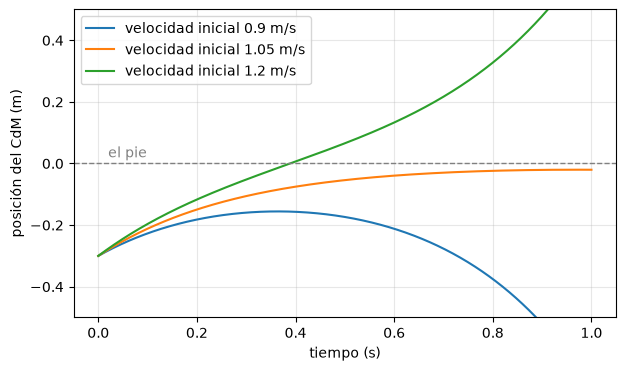

In [3]:
plt.figure(figsize=(7, 4))
for v_inicial in [0.9, 1.05, 1.2]:
    t, x, v = simular(-0.3, v_inicial, 0.0, 1.0)
    plt.plot(t, x, label=f"velocidad inicial {v_inicial} m/s")
plt.axhline(0, color="gray", ls="--", lw=1)
plt.text(0.02, 0.02, "el pie", color="gray")
plt.ylim(-0.5, 0.5)
plt.xlabel("tiempo (s)")
plt.ylabel("posición del CdM (m)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Tres destinos muy distintos:

- **0,9 m/s** (azul): no le da para llegar. El CdM avanza hacia el pie, frenándose (la gravedad tira hacia atrás mientras está por detrás), se para **antes** de llegar encima... y se cae **hacia atrás**.
- **1,2 m/s** (verde): le sobra. Pasa por encima del pie, y a partir de ahí la gravedad ya no lo frena sino que lo **acelera**: se cae **hacia delante**.
- **1,05 m/s** (naranja): ¡casi justo! Se acerca al pie frenándose cada vez más, y se queda prácticamente **quieto** a solo 2 cm de estar encima. (Le falta un pelín de velocidad: la justa, como veremos ahora, era 1,051.)

Esto es lo que pasa en cada paso que das: tu CdM llega por detrás del pie de apoyo con una velocidad, pasa por encima y se va por delante, y entonces tienes que poner el **otro** pie. Pero antes, la pregunta interesante: ¿cuál es exactamente la velocidad que lo deja quieto encima?


## 5 · La velocidad justa y la "energía orbital"

En el péndulo invertido lineal aparece un número que lo gobierna todo:

```
   ω  =  √(g / z0)
```

(**ω** es la letra griega "omega". **√** es la **raíz cuadrada**: el número que, multiplicado por sí mismo, da lo de dentro; √9 = 3 porque 3 × 3 = 9. En Python, `math.sqrt`.) Para nuestro robot:


In [4]:
omega = math.sqrt(g / z0)
print(round(omega, 3))

3.502


**3,502**. Su unidad es "1 por segundo" (1/s): mide **lo deprisa que se cae** el péndulo. Un robot más bajo tendría un ω mayor (cae más deprisa); uno más alto, menor.

Y aquí viene la clave. Los físicos descubrieron que, en el péndulo invertido lineal, hay una cantidad que **no cambia nunca** mientras el pie no se mueve:

```
   energía orbital  =  v²  −  ω² × (x − p)²
```

A medida que el CdM se mueve, la velocidad v cambia y la distancia al pie (x − p) cambia, pero esta combinación se queda **exactamente igual** todo el rato. Se llama **energía orbital** (es pariente de la energía del NB38b: no es exactamente cinética más potencial, pero se usa con el mismo truco, "si no cambia, el principio te dice el final"). No me creas: compruébalo con la simulación de 0,9 m/s, mirando el principio, la mitad y el final:


In [5]:
t, x, v = simular(-0.3, 0.9, 0.0, 1.0)
for i in [0, 500, 1000]:
    energia = v[i] ** 2 - omega ** 2 * (x[i] - 0.0) ** 2
    print(f"t = {t[i]:.1f} s:  x = {x[i]:+.3f}, v = {v[i]:+.3f}  →  energía orbital = {energia:.3f}")

t = 0.0 s:  x = -0.300, v = +0.900  →  energía orbital = -0.294
t = 0.5 s:  x = -0.174, v = -0.269  →  energía orbital = -0.298
t = 1.0 s:  x = -0.730, v = -2.494  →  energía orbital = -0.319


La posición y la velocidad cambian muchísimo (al final se está cayendo hacia atrás a toda velocidad), pero la energía orbital se queda en torno a **−0,3**. La pequeña deriva (de −0,294 a −0,319) no es física: es el error de la cadena de oro a pasitos que vimos en el NB07, que crece cuando todo va deprisa. Con pasitos diez veces más pequeños, al final del segundo vale −0,296: casi exactamente lo mismo que al principio.

¿Para qué sirve? Para responder a la pregunta: ¿cuándo se queda **quieto encima** del pie? "Quieto encima" significa v = 0 y x = p a la vez, y en ese instante la energía orbital vale 0² − ω² × 0² = **0**. Como la energía orbital no cambia, si al final vale 0, **tenía que valer 0 desde el principio**:

```
   v²  =  ω² × (x − p)²       →       v  =  ω × (distancia al pie)
```

La velocidad justa es **ω por la distancia** que le falta para llegar encima del pie. Para nuestros 0,3 m:


In [6]:
print(round(omega * 0.3, 3), "m/s")

1.051 m/s


**1,051 m/s**: la naranja de la gráfica (1,05) era casi exactamente esa. Con menos, se cae hacia atrás (energía orbital negativa); con más, pasa por encima y cae hacia delante (energía orbital positiva). El signo de la energía orbital te dice el destino.


## 6 · El punto de captura: dónde pisar para frenarte

Ahora le damos la vuelta a la pregunta, y esta es la pregunta **importante** para un robot.

Imagina que el robot está de pie, quieto, con el CdM encima del pie (x = 0, p = 0), y alguien le da un **empujón** por la espalda: de repente su CdM va hacia delante a **0,5 m/s**. Va a caerse hacia delante. Para no caerse, tiene que dar un paso. ¿**Dónde** tiene que poner el pie para frenarse del todo y quedar quieto, en equilibrio, encima de él?

Con la energía orbital es fácil. Queremos un pie **p** tal que la energía orbital sea 0: v = ω × (p − x). Despejando la p:

```
   punto de captura  =  x  +  v / ω
```

A este punto se le llama **punto de captura** (*capture point*; lo propusieron Jerry Pratt y su equipo en 2006). Es el sitio del suelo donde, si pones el pie, **tu caída se frena justo** y quedas quieto encima. En nuestro robot empujado:


In [7]:
x, v = 0.0, 0.5
punto_de_captura = x + v / omega
print(round(punto_de_captura, 3), "m")

0.143 m


**14,3 cm** por delante. Probemos a pisar justo ahí, y también 2 cm antes y 2 cm después:

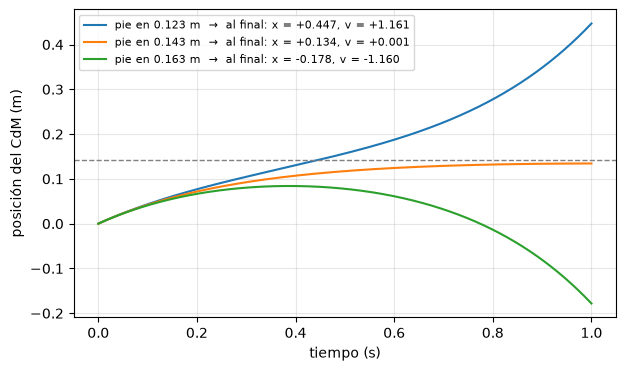

In [8]:
plt.figure(figsize=(7, 4))
for donde in [punto_de_captura - 0.02, punto_de_captura, punto_de_captura + 0.02]:
    t, xs, vs = simular(0.0, 0.5, donde, 1.0)
    plt.plot(t, xs, label=f"pie en {donde:.3f} m  →  al final: x = {xs[-1]:+.3f}, v = {vs[-1]:+.3f}")
plt.axhline(punto_de_captura, color="gray", ls="--", lw=1)
plt.xlabel("tiempo (s)")
plt.ylabel("posición del CdM (m)")
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.show()

(Para simplificar, el pie se pone **al instante** del empujón. En la realidad, mover la pierna tarda un poco, y durante ese rato el punto de captura se va alejando: hay que pisar donde **estará**.)

- Pisando **en el punto de captura** (naranja): el CdM avanza, se va frenando y se queda casi quieto (velocidad 0,001 m/s), a menos de un centímetro del pie. **Capturado.**
- Pisando **2 cm antes** (azul): el CdM pasa por encima del pie y se cae hacia delante. Habría que dar **otro** paso.
- Pisando **2 cm después** (verde): el pie está demasiado lejos; el CdM no llega y se cae **hacia atrás**.

¡Dos centímetros deciden el destino! Por eso el equilibrio dinámico es tan delicado, y por eso los robots reales **corrigen** constantemente: después de pisar, ajustan con el tobillo (lo vemos ahora) o con el siguiente paso.

Fíjate en la fórmula, porque es preciosa: **x + v / ω**. Es "dónde está el CdM, **más** un trozo extra proporcional a su velocidad". Cuanto más rápido vas, más lejos tienes que pisar para frenarte. Exactamente lo que haces sin pensar cuando corres y quieres parar en seco: el último paso lo das muy por delante.


## 7 · Recuperarse de un empujón: tobillo o paso

¿Siempre hace falta dar un paso? No. Un robot (o tú) con **pies de verdad**, no de punta, tiene un truco anterior: el **tobillo**.

Con el pie plano en el suelo, apretando más con la **punta** o con el **talón**, puedes mover el punto en el que el suelo te empuja, **dentro** del pie. (Haz la prueba de pie: inclínate un poco hacia delante y notarás que aprietas los dedos de los pies contra el suelo.) Para el péndulo invertido lineal, eso es como **mover un poco la p**, sin levantar el pie. Si el punto de captura cae **dentro** del pie, basta con llevar ahí el punto de apoyo apretando con el tobillo, y el robot se frena **sin dar ningún paso**. Es la **estrategia del tobillo**.

Si el punto de captura cae **fuera** del pie, el tobillo no basta: el punto de apoyo no puede salir del pie (NB38: el suelo empuja solo donde lo tocas). Hay que **dar un paso**: la **estrategia del paso**.

¿Cuál es el empujón más grande que aguanta nuestro robot sin dar un paso? Supongamos un pie como el de un humano, cuya punta queda unos **15 cm** por delante del tobillo, y el CdM justo encima del tobillo (x = 0). El punto de captura tiene que quedar dentro del pie: v / ω ≤ 0,15, o sea:


In [9]:
print(round(omega * 0.15, 2), "m/s")

0.53 m/s


Empujones que le den hasta **0,53 m/s** se aguantan solo con el tobillo. A partir de ahí, toca dar un paso. Y si el empujón es tan fuerte que el punto de captura queda **más lejos de lo que alcanza la pierna en un paso**, ni siquiera un paso basta: hacen falta **varios**, frenando un poco en cada uno (como cuando te empujan fuerte y das tres o cuatro pasos tambaleándote). Lo simularás en el ejercicio E5.


## 8 · El ZMP: el punto en el que el suelo te empuja

Ahora el concepto más famoso de la robótica bípeda. Lo propuso el ingeniero serbio **Miomir Vukobratović** a finales de los años 60, y con él andaban **ASIMO** de Honda y casi todos los humanoides de los años 90 y 2000.

Cuando estás de pie, el suelo te empuja en **todos** los puntos de la planta de los pies, más en unos que en otros. Pero, igual que el peso de todas tus piezas se puede sustituir por un único peso en el centro de masas (NB38), todos esos empujones del suelo se pueden sustituir por **un único empujón** aplicado en un punto. Ese punto se llama **centro de presión**, y en un suelo plano coincide con el **ZMP** (*Zero Moment Point*, "punto de momento cero": el punto alrededor del cual los empujones del suelo no producen giro).

En el péndulo invertido lineal, el ZMP es justo la **p**: el punto de apoyo. Y si despejamos la p de la ecuación de la sección 3 (aceleración = (g / z0) × (x − p)), sale una fórmula muy útil:

```
   ZMP  =  x  −  (z0 / g) × aceleración del CdM
```

Dice: "si conozco **cómo se mueve** mi centro de masas (su posición y su aceleración), sé **dónde** me tiene que estar empujando el suelo".


### El caso quieto: ¡el NB38!

Si el robot está **quieto** (aceleración 0), la fórmula dice: ZMP = x. El suelo te empuja **justo debajo del centro de masas**. Y como el suelo solo puede empujar en los puntos de la base de apoyo, el ZMP (la vertical del CdM) tiene que estar **dentro** de la base... ¡que es exactamente la regla del equilibrio quieto del NB38!

La regla del NB38 era un **caso particular** de esta. La regla general es:

> **El ZMP tiene que estar siempre dentro de la base de apoyo.** Si los movimientos que quieres hacer exigen un ZMP fuera de la base, el pie **volcará** sobre su borde.

### El caso en movimiento

Un ejemplo: el robot quiere **acelerar** hacia delante, a 1 m/s², con el CdM justo encima del tobillo (x = 0). ¿Dónde tiene que empujarle el suelo?


In [10]:
x, aceleracion = 0.0, 1.0
zmp = x - (z0 / g) * aceleracion
print(round(zmp, 3), "m")

-0.082 m


**−8,2 cm**: el ZMP tiene que estar **detrás** del CdM, hacia el **talón**. Tiene sentido: para que el suelo te empuje hacia delante, tienes que empujarlo tú hacia atrás, apretando con el talón (fíjate en cómo arrancas a correr: te inclinas y empujas). Si el talón del robot está a menos de 8,2 cm detrás del tobillo, esa aceleración es **imposible** sin que el pie se levante por la punta.

Así andaba ASIMO: sus ingenieros **planificaban** con antelación cómo iba a moverse el centro de masas en los siguientes pasos, calculaban el ZMP que exigía ese movimiento, y comprobaban que siempre caía **dentro** del pie de apoyo, con margen (NB38). Si no, cambiaban el plan. Por eso ASIMO andaba de esa forma tan característica, con las rodillas dobladas (¡altura constante, el péndulo lineal!) y pasos cortos y cuidadosos.


## 9 · Andar: encadenar caídas

Juntemos todo. Andar es caer hacia delante y poner el pie a tiempo, una y otra vez. Con el punto de captura podemos fabricar una forma de andar en unas pocas líneas:

- El robot apoya un pie y su CdM se mueve según el péndulo invertido lineal durante un tiempo fijo, **0,4 s** (la duración de un paso).
- Cuando se acaba el tiempo, calcula su punto de captura y pone el otro pie un poquito **antes** de él: una distancia **b**.

¿Por qué antes? Porque si pisara justo **en** el punto de captura, se frenaría y se pararía (sección 6). Pisando un poco antes, el CdM pasará por encima del pie con algo de velocidad y seguirá avanzando: no se frena del todo. Es como **quedarse corto a propósito** al frenar.


In [11]:
def andar(b, duracion_paso=0.4, n_pasos=10, v_inicial=0.5):
    x, v, p = 0.0, v_inicial, 0.0                  # empezamos con el CdM encima del primer pie, avanzando
    pies, tiempos, posiciones = [p], [], []
    t = 0.0
    for paso_n in range(n_pasos):
        for i in range(round(duracion_paso / paso)):
            aceleracion = (g / z0) * (x - p)
            v = v + aceleracion * paso
            x = x + v * paso
            t = t + paso
            tiempos.append(t)
            posiciones.append(x)
        p = (x + v / omega) - b                     # el siguiente pie: b antes del punto de captura
        pies.append(p)
    return pies, tiempos, posiciones, v

Es la función `simular` metida en un bucle de pasos, con una línea nueva: la que coloca el siguiente pie. Probemos con b = 0,1 m y dibujemos el CdM y las pisadas:

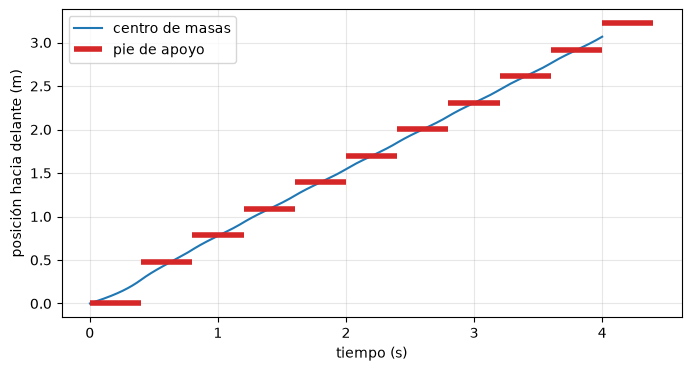

largo de cada paso: [0.479 0.304 0.304 0.304 0.304 0.304 0.304 0.304 0.304 0.304]


In [12]:
pies, tiempos, posiciones, v_final = andar(b=0.1)

plt.figure(figsize=(8, 4))
plt.plot(tiempos, posiciones, label="centro de masas")
for k, pie in enumerate(pies):
    plt.hlines(pie, k * 0.4, (k + 1) * 0.4, color="tab:red", lw=4, label="pie de apoyo" if k == 0 else None)
plt.xlabel("tiempo (s)")
plt.ylabel("posición hacia delante (m)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
print("largo de cada paso:", np.round(np.diff(pies), 3))

(`plt.hlines` dibuja una raya horizontal: cada raya roja es un pie apoyado durante sus 0,4 s. `np.diff` da las diferencias entre elementos seguidos de una lista, NB27: aquí, lo que avanza cada paso.)

¡El robot **anda**! El CdM (azul) avanza de forma casi regular, y las pisadas (rojo) van apareciendo por delante, cada una un poco más allá. Fíjate en el largo de los pasos: después de un primer paso un poco distinto (el arranque), se estabilizan solos en **0,30 m**, siempre iguales. La marcha se ha vuelto **periódica**, como un reloj, sin que se lo hayamos pedido.

¿Y qué pasa si cambiamos la **b**, lo que nos quedamos cortos?


In [13]:
for b in [0.05, 0.10, 0.15]:
    pies, tiempos, posiciones, v_final = andar(b)
    largo = pies[-1] - pies[-2]
    print(f"b = {b:.2f} m  →  pasos de {largo:.3f} m cada {0.4} s  =  {largo / 0.4:.2f} m/s de media")

b = 0.05 m  →  pasos de 0.152 m cada 0.4 s  =  0.38 m/s de media
b = 0.10 m  →  pasos de 0.304 m cada 0.4 s  =  0.76 m/s de media
b = 0.15 m  →  pasos de 0.457 m cada 0.4 s  =  1.14 m/s de media


Cuanto **más corto** nos quedamos del punto de captura, **más deprisa** anda el robot: pasos más largos en el mismo tiempo. Con b = 0,05 va a menos de 0,4 m/s (un paseo); con b = 0,15, a más de 1,1 m/s (un paso ligero). Para **acelerar**, pisa más cerca de ti; para **frenar**, pisa más lejos, en el punto de captura o más allá. Esto lo hace tu cerebro en cada paso, y un buen controlador de robot, también.


## 10 · Los límites del modelo, y qué tiene que ver con el RL

Recuerda: "todos los modelos están mal, pero algunos son útiles". El péndulo invertido lineal ignora muchísimo:

- **La altura no es constante** del todo, y al correr hay fases en el **aire** (NB35) en las que no hay pie de apoyo.
- El robot **no es un punto**: tiene inercia de giro (NB37), brazos que se balancean, un torso que se inclina.
- Las piernas tienen **masa** (¡el pie de Hopper era la pieza más pesada!) y tardan en moverse.
- Los motores tienen **límites** de par y velocidad (NB37, NB40).

Aun así, es una herramienta de primera: robots como Atlas de Boston Dynamics o los humanoides de muchos laboratorios usan versiones mejoradas de estas ideas (con el CdM más realista y planificando muchos pasos por delante con optimización, la **MPC**, *control predictivo*) para decidir dónde pisar.

¿Y el aprendizaje por refuerzo? Una política de RL como las del NB35 **no** sabe nada de puntos de captura ni de ZMP. Aprende a poner el pie en el sitio justo a base de millones de intentos. Pero:

- **Si sabes** dónde debería pisar un robot, puedes **diagnosticar** una política: "se cae porque pisa siempre 5 cm antes del punto de captura".
- Puedes darle a la política el **punto de captura** como una observación más, y le resulta más fácil aprender (le das masticado algo que tendría que descubrir sola).
- Puedes usarlo en la **recompensa**, para premiar pisadas razonables (*reward shaping*, NB35).
- Y muchos robots reales combinan las dos cosas: un controlador clásico basado en estos modelos y una política de RL que lo corrige o lo sustituye en las partes difíciles.

Un ingeniero de locomoción que solo sabe RL y uno que solo sabe modelos están, los dos, cojos. Tú vas a saber las dos cosas.


## 11 · Resumen de la lección

1. Un **modelo** es una simplificación útil ("el mapa no es el territorio"; "todos los modelos están mal, pero algunos son útiles").
2. **Péndulo invertido**: toda la masa en el CdM, sobre una pierna sin masa apoyada en el pie.
3. **Péndulo invertido lineal (LIPM)**: CdM a altura constante z0. La pierna empuja a lo largo de sí misma (triángulos semejantes) y sale: **aceleración = (g / z0) × (x − p)**. Exacta, sin senos; la masa se cancela.
4. Según la velocidad con que el CdM se acerca al pie, vuelve atrás, se para encima o pasa por encima.
5. **ω = √(g / z0)** (3,5 por segundo con z0 = 0,8 m). La **energía orbital** v² − ω²(x − p)² no cambia mientras el pie no se mueve; su signo dice el destino. Velocidad justa para pararse encima: ω × distancia.
6. **Punto de captura = x + v / ω**: donde hay que pisar para frenarse y quedar quieto. 2 cm de error ya bastan para caer.
7. **Estrategia del tobillo** (mover el apoyo dentro del pie, si el punto de captura cae dentro) vs **estrategia del paso** (si cae fuera). Empujón máximo sin pasos: ω × (distancia del CdM a la punta).
8. **ZMP** (= centro de presión en suelo plano) = **x − (z0 / g) × aceleración**. Debe estar **dentro de la base**. Quieto, es la vertical del CdM: la regla del NB38 es un caso particular. Así andaba ASIMO.
9. **Andar** = pisar **b** antes del punto de captura en cada paso: la marcha se vuelve periódica sola, y más rápida cuanto mayor es b.
10. El modelo tiene límites, pero sirve para diagnosticar políticas de RL, darles observaciones útiles y moldear recompensas.

### Palabras nuevas de hoy

| Palabra | Qué significa |
|---|---|
| **Modelo** | Versión simplificada a propósito de algo real, útil para pensar y calcular. |
| **Péndulo invertido (lineal), LIPM** | Masa en un punto sobre una pierna sin masa (con el CdM a altura constante). |
| **Triángulos semejantes** | Triángulos con la misma forma y distinto tamaño: sus lados guardan la misma proporción. |
| **Raíz cuadrada (√)** | El número que multiplicado por sí mismo da el de dentro (`math.sqrt`). |
| **ω (omega)** | √(g / z0): lo deprisa que se cae el péndulo invertido lineal. |
| **Energía orbital** | v² − ω²(x − p)²: no cambia mientras el pie no se mueve. |
| **Punto de captura** | x + v / ω: donde pisar para frenarse del todo. |
| **Estrategia del tobillo / del paso** | Recuperarse moviendo el apoyo dentro del pie / dando un paso. |
| **Centro de presión** | El punto donde actúa el empujón total del suelo. |
| **ZMP (punto de momento cero)** | En suelo plano, el centro de presión; debe estar dentro de la base de apoyo. |
| **Marcha periódica** | Forma de andar que se repite igual paso tras paso. |
| **MPC (control predictivo)** | Planificar los próximos movimientos optimizando, y replanificar a menudo. |


## 12 · Ejercicios

**E1.** Calcula ω para un robot pequeño con el CdM a 0,3 m de altura y para uno grande con el CdM a 1,2 m. ¿Cuál se cae más deprisa? ¿Cuál es más fácil de equilibrar, según el NB37?

**E2.** El CdM está 0,2 m **por detrás** del pie y va hacia delante a 0,6 m/s (con z0 = 0,8). Calcula su energía orbital. ¿Se parará antes de llegar encima del pie, o lo pasará? Compruébalo con `simular`.

**E3.** Un robot quieto (x = 0) recibe un empujón que le da 1,2 m/s hacia delante. ¿Dónde está su punto de captura? Si su pie llega como mucho a 0,15 m por delante del tobillo y su pierna puede dar pasos de hasta 0,4 m, ¿le basta el tobillo? ¿Le basta un paso?

**E4.** Con la fórmula del ZMP: el robot (CdM a 0,8 m) quiere **frenar** a 2 m/s² (aceleración −2) con el CdM encima del tobillo. ¿Dónde tiene que estar el ZMP? Si la punta del pie está a 0,15 m, ¿puede hacerlo?

**E5.** **Reto.** Escribe una función que simule la recuperación de un empujón **con pasos limitados**: el robot recibe un empujón de 1,5 m/s; cada 0,3 s puede dar un paso, pero el pie nuevo no puede quedar a más de 0,4 m por delante del CdM. En cada paso, pisa en el punto de captura si está a su alcance, y si no, lo más lejos que pueda. ¿Cuántos pasos necesita para quedarse quieto?

**E6.** En `andar`, prueba b = 0 (pisar justo en el punto de captura en cada paso) y b negativo (pisar más allá del punto de captura). ¿Qué hace el robot en cada caso?


<details>
<summary>▶ Solución E1</summary>

```python
for altura in [0.3, 1.2]:
    print(altura, round(math.sqrt(g / altura), 2))
```

Con el CdM a 0,3 m, ω ≈ **5,72** por segundo; a 1,2 m, ω ≈ **2,86**. El bajito se cae el **doble de deprisa** (ω mide la rapidez de la caída). Es la escoba contra el lápiz del NB37: el robot alto da más tiempo para reaccionar. A cambio, el alto tiene que dar pasos más largos para frenar el mismo empujón, porque su punto de captura (x + v / ω) está más lejos.
</details>

<details>
<summary>▶ Solución E2</summary>

Energía orbital = 0,6² − 3,502² × (−0,2)² = 0,36 − 12,26 × 0,04 = 0,36 − 0,49 ≈ **−0,13**. Es **negativa**: no le da para llegar encima del pie. Se parará antes y caerá hacia atrás. (La velocidad justa sería ω × 0,2 ≈ 0,70 m/s.)

```python
print(round(0.6 ** 2 - omega ** 2 * 0.2 ** 2, 3))
t, x, v = simular(-0.2, 0.6, 0.0, 1.0)
print("posición más adelantada:", round(max(x), 3), "| velocidad al final:", round(v[-1], 2))
```

El CdM llega como mucho a unos 10 cm del pie (sin llegar a 0) y al final va hacia atrás.
</details>

<details>
<summary>▶ Solución E3</summary>

Punto de captura = 0 + 1,2 / 3,502 ≈ **0,343 m**. El tobillo **no** basta (la punta del pie está a 0,15 m, y 0,343 queda fuera). **Un paso sí basta**: 0,343 m es menos que los 0,4 m que alcanza la pierna. Si pisa ahí, se frena del todo con un único paso.

```python
print(round(1.2 / omega, 3))
```
</details>

<details>
<summary>▶ Solución E4</summary>

ZMP = 0 − (0,8 / 9,81) × (−2) ≈ **+0,163 m**: tiene que estar **por delante** del CdM, hacia la punta (para frenar, empujas el suelo hacia delante con la punta del pie). Pero la punta solo llega a 0,15 m: el ZMP necesario queda **fuera** del pie. **No puede** frenar tan fuerte solo con el pie: el pie volcaría sobre la punta. Tendría que frenar más suave (como mucho, una aceleración de −0,15 × 9,81 / 0,8 ≈ −1,84 m/s²) o dar un paso.

```python
print(round(-(z0 / g) * (-2), 3), round(-0.15 * g / z0, 2))
```
</details>

<details>
<summary>▶ Solución E5</summary>

```python
def recuperar(v_empujon, duracion_paso=0.3, alcance=0.4, max_pasos=10):
    x, v = 0.0, v_empujon
    for n in range(1, max_pasos + 1):
        captura = x + v / omega
        if captura <= x + alcance:                   # ¡el punto de captura está a su alcance!
            print(f"paso {n}: pie en el punto de captura, {captura:.3f}  →  CAPTURADO")
            return n
        p = x + alcance                              # no llega: pisa lo más lejos que puede
        for i in range(round(duracion_paso / paso)):
            v = v + (g / z0) * (x - p) * paso
            x = x + v * paso
        print(f"paso {n}: pie en {p:.3f} (la captura estaba en {captura:.3f})  →  tras el paso, v = {v:+.3f} m/s")
    return None

print("pasos necesarios:", recuperar(1.5))
print("pasos necesarios:", recuperar(2.5))
```

Con **1,5 m/s**, el primer punto de captura está a 0,43 m, un poco más allá de lo que alcanza la pierna (0,4 m). El primer paso se queda corto y no lo frena del todo, pero lo **ralentiza** (de 1,5 a unos 0,65 m/s). Con esa velocidad, el siguiente punto de captura ya está a su alcance: **2 pasos**. Con **2,5 m/s** hacen falta **4 pasos**: cada paso corto frena solo una parte (2,5 → 2,25 → 1,85 → 1,20 m/s) hasta que uno "llega". Es lo que haces cuando te empujan fuerte: varios pasos tambaleándote. Y con **3 m/s** sale `None`: cada paso corto ya **no** frena lo suficiente, la velocidad **crece** paso a paso y el robot se embala hasta caer. Hay un empujón máximo a partir del cual ni siquiera dar pasos te salva (por eso los humanos, cuando nos empujan muy fuerte, acabamos en el suelo aunque demos pasos).
</details>

<details>
<summary>▶ Solución E6</summary>

```python
for b in [0.0, -0.05]:
    pies, tiempos, posiciones, v_final = andar(b)
    print(b, np.round(np.diff(pies), 3), round(v_final, 3))
```

Con **b = 0** pisa justo en el punto de captura: el primer paso lo frena por completo, y a partir de ahí los "pasos" miden prácticamente 0: el robot se ha **parado**. Con **b negativo** pisa **más allá** del punto de captura: el CdM no llega a pasar por encima del pie y se vuelve hacia atrás... y el robot acaba **andando hacia atrás**. La b es como el pedal de un coche: positiva acelera hacia delante, cero frena, negativa da marcha atrás.
</details>


## 13 · Posdata

Si algo no ha quedado claro, dime el **apartado** y la **frase exacta** y lo reescribo.

Hasta ahora hemos tratado los motores como cajas que "hacen un par" cuando se les pide. En el **NB40** abrimos la caja: cómo es un motor eléctrico de verdad, por qué casi todos los robots llevan **reductoras**, qué límites tienen (de par, de velocidad, de calor) y, sobre todo, cómo se le ordena a un motor que lleve una articulación a un ángulo: el **control PD**, el controlador más usado de la robótica, que está también **dentro** de casi todas las políticas de RL de robots reales.
